<a href="https://colab.research.google.com/github/lt33tx/Landon_Tinch_DTSC3020_Fall2025-/blob/main/Assignment_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Quality Check

1.1 Using Python (pandas, matplotlib, or seaborn), load and inspect the Assignment 2 dataset.

In [1]:
# Write your code here

from google.colab import files
uploaded = files.upload()


Saving Assignment 2 dataset.csv to Assignment 2 dataset.csv


Write code to explore the data distribution (e.g., region, type, year) and check whether there is any bias. Provide both the code and your interpretation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18254 entries, 0 to 18253
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Column 1      18254 non-null  int64  
 1   Date          18254 non-null  object 
 2   AveragePrice  18254 non-null  float64
 3   Total Volume  18253 non-null  float64
 4   4046          18252 non-null  float64
 5   4225          18253 non-null  float64
 6   4770          18253 non-null  float64
 7   Total Bags    18253 non-null  float64
 8   Small Bags    18252 non-null  float64
 9   Large Bags    18252 non-null  float64
 10  XLarge Bags   18253 non-null  float64
 11  type          18253 non-null  object 
 12  year          18254 non-null  int64  
 13  region        18254 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
None
Column 1        0
Date            0
AveragePrice    0
Total Volume    1
4046            2
4225            1
4770            1
Total Bags

/tmp/ipython-input-4137763686.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, ax=axes[0], palette="viridis")
/tmp/ipython-input-4137763686.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, ax=axes[1], palette="pastel")
/tmp/ipython-input-4137763686.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, ax=axes[2], palette="rocket")


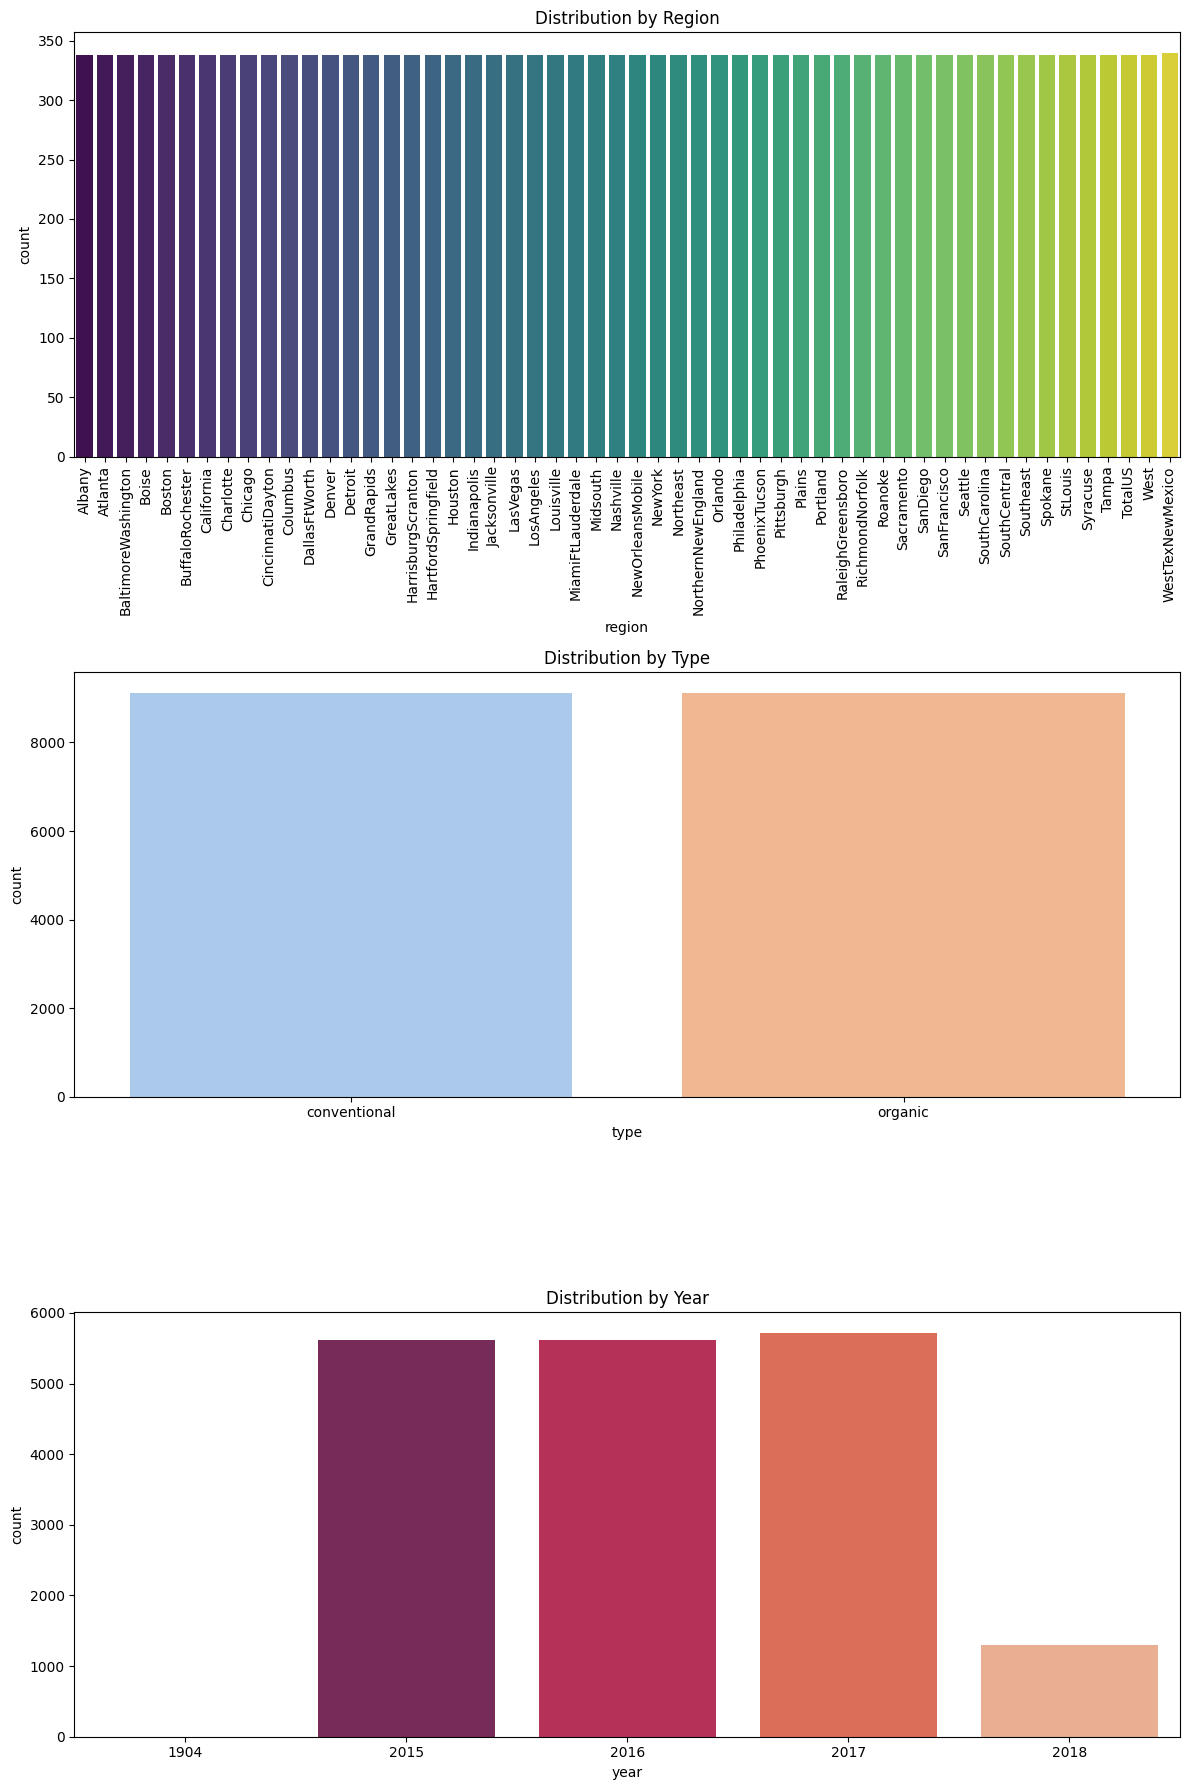

year
2017    5722
2016    5616
2015    5615
2018    1300
1904       1
Name: count, dtype: int64
       Column 1       Date  AveragePrice  Total Volume     4046     4225  \
18250         9  1-21-1904          1.87      13766.76  1191.92  2452.79   

         4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18250  727.94     9394.11      9351.8       42.31          0.0  organic  1904   

                 region  
18250  WestTexNewMexico  


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading the dataset into a dataframe
df = pd.read_csv('Assignment 2 dataset.csv')

# basic overview of the dataset structure
print(df.info())

# checking how many missing values each column has
print(df.isnull().sum())

# setting up 3 stacked plots for visualizing distributions
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# counting how many entries are in each region
sns.countplot(x='region', data=df, ax=axes[0], palette="viridis")
axes[0].set_title('Distribution by Region')
axes[0].tick_params(axis='x', rotation=90)  # rotates labels so they’re readable

# counting how many entries belong to each type
sns.countplot(x='type', data=df, ax=axes[1], palette="pastel")
axes[1].set_title('Distribution by Type')

# showing how many entries there are for each year
sns.countplot(x='year', data=df, ax=axes[2], palette="rocket")
axes[2].set_title('Distribution by Year')

plt.tight_layout()  # helps keep plots from overlapping
plt.show()

# shows how many rows appear for each year value
print(df['year'].value_counts())

# checking all rows where the year is 1904
print(df[df['year'] == 1904])

#I found 2 duplicate rows. Since exact duplicates don’t normally add new info and might just be entered incorrectly, the best choice is to just drop them.

#There are a few missing values in many different areas.

#Since there are only a very few, I could just drop them. There are only like 1 or 2 per column out of more than 18,000. Dropping these rows seems like the best bet.

#Second option is just to insert a mean or median into the missing or errored column if I really need them.

#I have decided with the first option. It seems like the best choice with the lowest risk.

1.2 Write Python code to check for duplicate rows and missing values in the dataset. Show the number of duplicates and missing values for each column. Then, explain (in comments or markdown) how you would handle these issues (e.g., drop, impute, or replace).




In [3]:
import pandas as pd

# loading the dataset into a dataframe
df = pd.read_csv('Assignment 2 dataset.csv')

# checking how many duplicate rows there are
num_duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {num_duplicates}")

# if duplicates exist, print all of them
if num_duplicates > 0:
    print(df[df.duplicated(keep=False)])

# counting how many missing values each column has
missing_counts = df.isnull().sum()
print(missing_counts)


Total Duplicate Rows: 2
       Column 1       Date  AveragePrice  Total Volume     4046     4225  \
18244         7   2-4-2018          1.63      17074.83  2046.96  1529.20   
18247        10  1-14-2018          1.93      16205.22  1527.63  2981.04   
18249        10  1-14-2018          1.93      16205.22  1527.63  2981.04   
18253         7   2-4-2018          1.63      17074.83  2046.96  1529.20   

         4770  Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18244    0.00    13498.67    13066.82      431.85          0.0  organic  2018   
18247  727.01    10969.54    10919.54       50.00          0.0  organic  2018   
18249  727.01    10969.54    10919.54       50.00          0.0  organic  2018   
18253    0.00    13498.67    13066.82      431.85          0.0  organic  2018   

                 region  
18244  WestTexNewMexico  
18247  WestTexNewMexico  
18249  WestTexNewMexico  
18253  WestTexNewMexico  
Column 1        0
Date            0
AveragePrice    0
Total

1.3 Use Python code to print the number of rows and columns in the dataset (e.g., with df.shape). Based on the dataset size, explain (briefly) whether you think the dataset is sufficient for training a machine learning model.

In [26]:
import pandas as pd

# loading the dataset into a dataframe
df = pd.read_csv('Assignment 2 dataset.csv')

# printing the overall shape (rows, columns)
print(f"Shape: {df.shape}")

# number of rows in the dataset
print(f"Rows: {df.shape[0]}")

# number of columns in the dataset
print(f"Columns: {df.shape[1]}")

#There are 18,254 rows and 14 coloms that is plenty to train the model on

Shape: (18254, 14)
Rows: 18254
Columns: 14


#2. Data Cleaning and Preprocessing

2.1 Remove the first column or “Column 1” from the dataset. Treat the ‘year’ variable as nominal.

In [15]:
import pandas as pd

# loading the dataset into a dataframe
df = pd.read_csv('Assignment 2 dataset.csv')

# dropping a column we don't need anymore
df.drop(columns=['Column 1'], inplace=True)

# converting the year column to a string type
df['year'] = df['year'].astype(str)

# printing out all the column names
print(df.columns)

# showing the data types for each column
print(df.dtypes)


Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region'],
      dtype='object')
Date             object
AveragePrice    float64
Total Volume    float64
4046            float64
4225            float64
4770            float64
Total Bags      float64
Small Bags      float64
Large Bags      float64
XLarge Bags     float64
type             object
year             object
region           object
dtype: object


2.2 Check for duplicate values and remove them.

In [16]:
import pandas as pd

# loading the dataset
df = pd.read_csv('Assignment 2 dataset.csv')

# dropping a column we don't need + fixing year type
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)

# checking how many rows we started with and the number of duplicates
initial_rows = len(df)
num_duplicates = df.duplicated().sum()
print(f"Rows before cleaning: {initial_rows}")
print(f"Duplicates found: {num_duplicates}")

# if duplicates exist, show them
if num_duplicates > 0:
    print("\nDuplicate Rows:")
    print(df[df.duplicated(keep=False)])

# removing duplicate rows from the dataset
df.drop_duplicates(inplace=True)

# checking how many rows are left after cleaning
final_rows = len(df)
print(f"\nRows after cleaning: {final_rows}")

# confirming that duplicates are gone
if df.duplicated().sum() == 0:
    print("Success! No duplicates remaining.")


Rows before cleaning: 18254
Duplicates found: 2

Duplicate Rows:
            Date  AveragePrice  Total Volume     4046     4225    4770  \
18244   2-4-2018          1.63      17074.83  2046.96  1529.20    0.00   
18247  1-14-2018          1.93      16205.22  1527.63  2981.04  727.01   
18249  1-14-2018          1.93      16205.22  1527.63  2981.04  727.01   
18253   2-4-2018          1.63      17074.83  2046.96  1529.20    0.00   

       Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18244    13498.67    13066.82      431.85          0.0  organic  2018   
18247    10969.54    10919.54       50.00          0.0  organic  2018   
18249    10969.54    10919.54       50.00          0.0  organic  2018   
18253    13498.67    13066.82      431.85          0.0  organic  2018   

                 region  
18244  WestTexNewMexico  
18247  WestTexNewMexico  
18249  WestTexNewMexico  
18253  WestTexNewMexico  

Rows after cleaning: 18252
Success! No duplicates remaining.


2.3 Check for missing values. If a data record (row) only has a few missing values, replace the missing values with the median of the column feature in that specific “Region” variable. If most column values in a data record are missing, remove the data record.

In [17]:
import pandas as pd
import numpy as np

# loading the dataset and doing the basic cleanup steps
df = pd.read_csv('Assignment 2 dataset.csv')
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)
df.drop_duplicates(inplace=True)

# checking how many missing values each row has
missing_counts = df.isnull().sum(axis=1)

# showing any rows that contain missing data
rows_with_missing = df[missing_counts > 0]
print(f"Rows with missing data:\n{rows_with_missing}")

# figuring out which rows have too many missing values (over half)
threshold = len(df.columns) / 2
rows_to_drop = df[missing_counts > threshold].index

print(f"\nDropping {len(rows_to_drop)} row(s) because they have too many missing values.")
df.drop(index=rows_to_drop, inplace=True)

# selecting only the numeric columns for median imputation
numeric_cols = df.select_dtypes(include=[np.number]).columns

# filling numeric missing values with each region's median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        print(f"Imputing missing values in column '{col}' with regional medians...")
        df[col] = df[col].fillna(df.groupby('region')[col].transform('median'))

# filling missing 'type' values with the most common one
if df['type'].isnull().sum() > 0:
     mode_val = df['type'].mode()[0]
     df['type'] = df['type'].fillna(mode_val)

# final check to make sure everything is cleaned up
print("\n Final Check for Missing Values")
print(df.isnull().sum())
print(f"Final Dataset Shape: {df.shape}")


Rows with missing data:
            Date  AveragePrice  Total Volume  4046    4225  4770  Total Bags  \
18251  1-28-2018          1.71      13888.04   NaN  3431.5   0.0     9264.84   
18252   1-7-2018          1.62           NaN   NaN     NaN   NaN         NaN   

       Small Bags  Large Bags  XLarge Bags     type  year            region  
18251         NaN         NaN          0.0  organic  2018  WestTexNewMexico  
18252         NaN         NaN          NaN      NaN  2018  WestTexNewMexico  

Dropping 1 row(s) because they have too many missing values.
Imputing missing values in column '4046' with regional medians...
Imputing missing values in column 'Small Bags' with regional medians...
Imputing missing values in column 'Large Bags' with regional medians...

 Final Check for Missing Values
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            

2.4 Find the correlation between the variables and describe how the correlated values among the variables impact the model accuracy.


              AveragePrice  Total Volume      4046      4225      4770  \
AveragePrice      1.000000     -0.192767 -0.208324 -0.172944 -0.179458   
Total Volume     -0.192767      1.000000  0.977863  0.974181  0.872203   
4046             -0.208324      0.977863  1.000000  0.926110  0.833390   
4225             -0.172944      0.974181  0.926110  1.000000  0.887856   
4770             -0.179458      0.872203  0.833390  0.887856  1.000000   
Total Bags       -0.177103      0.963047  0.920057  0.905788  0.792315   
Small Bags       -0.174738      0.967238  0.925280  0.916031  0.802733   
Large Bags       -0.172948      0.880640  0.838645  0.810016  0.698472   
XLarge Bags      -0.117604      0.747158  0.699378  0.688810  0.679862   

              Total Bags  Small Bags  Large Bags  XLarge Bags  
AveragePrice   -0.177103   -0.174738   -0.172948    -0.117604  
Total Volume    0.963047    0.967238    0.880640     0.747158  
4046            0.920057    0.925280    0.838645     0.699378  
422

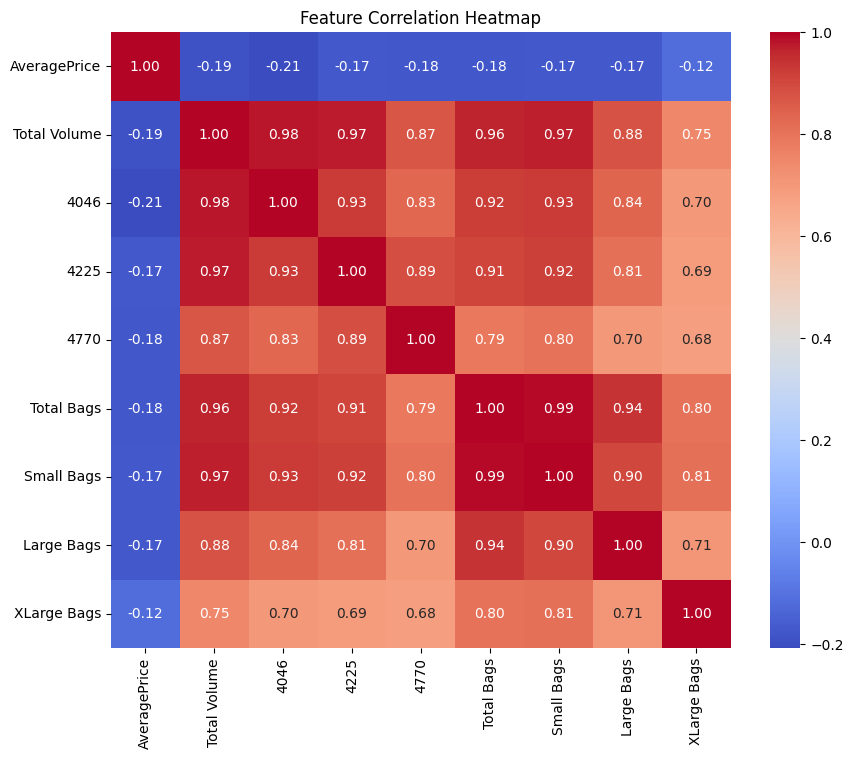

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# loading the dataset and doing basic cleanup
df = pd.read_csv('Assignment 2 dataset.csv')
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)
df.drop_duplicates(inplace=True)

# grabbing only the numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# calculating the correlation matrix
corr_matrix = numeric_df.corr()

# printing the matrix to see the raw numbers
print(corr_matrix)

# plotting a heatmap to visualize how features relate to each other
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

#Total volume is extremely correlated with 4046 and 4225 and total bags. This makes sense, as it is quite literally the sum of the parts.

#The total bags and small bags have a correlation of 0.99. Again, this makes sense since the vast majority of the bags are likely small bags.

#The model is accurate at price predictions, but it doesn’t help us understand what specifically is driving the prices, as when the total volume goes up, stuff like the small bags also goes up, so it’s hard to tell which of the two is the main driver.


#3. Exploratory Data Analysis (EDA)


3.1 Describe the variables
- Describe all variables in the dataset.
- For continuous variables: report **range (min, max), mean, median, and distribution**.
- For categorical variables: list unique values.

Continuous Variables: ['AveragePrice', 'Total Volume', '4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']
Categorical Variables: ['Date', 'type', 'year', 'region']

Variable: AveragePrice
  Range: 0.44 to 3.25
  Mean: 1.41
  Median: 1.37
  Std Dev: 0.40

Variable: Total Volume
  Range: 84.56 to 62505646.52
  Mean: 850552.31
  Median: 107354.25
  Std Dev: 3453367.22

Variable: 4046
  Range: 0.0 to 22743616.17
  Mean: 292983.95
  Median: 8645.30
  Std Dev: 1264922.13

Variable: 4225
  Range: 0.0 to 20470572.61
  Mean: 295122.55
  Median: 29056.73
  Std Dev: 1204058.31

Variable: 4770
  Range: 0.0 to 2546439.11
  Mean: 22837.27
  Median: 184.99
  Std Dev: 107458.44

Variable: Total Bags
  Range: 0.0 to 19373134.37
  Mean: 239613.96
  Median: 39738.53
  Std Dev: 986191.30

Variable: Small Bags
  Range: 0.0 to 13384586.8
  Mean: 182178.42
  Median: 26362.82
  Std Dev: 746139.29

Variable: Large Bags
  Range: 0.0 to 5719096.61
  Mean: 54332.33
  Median: 2647.71


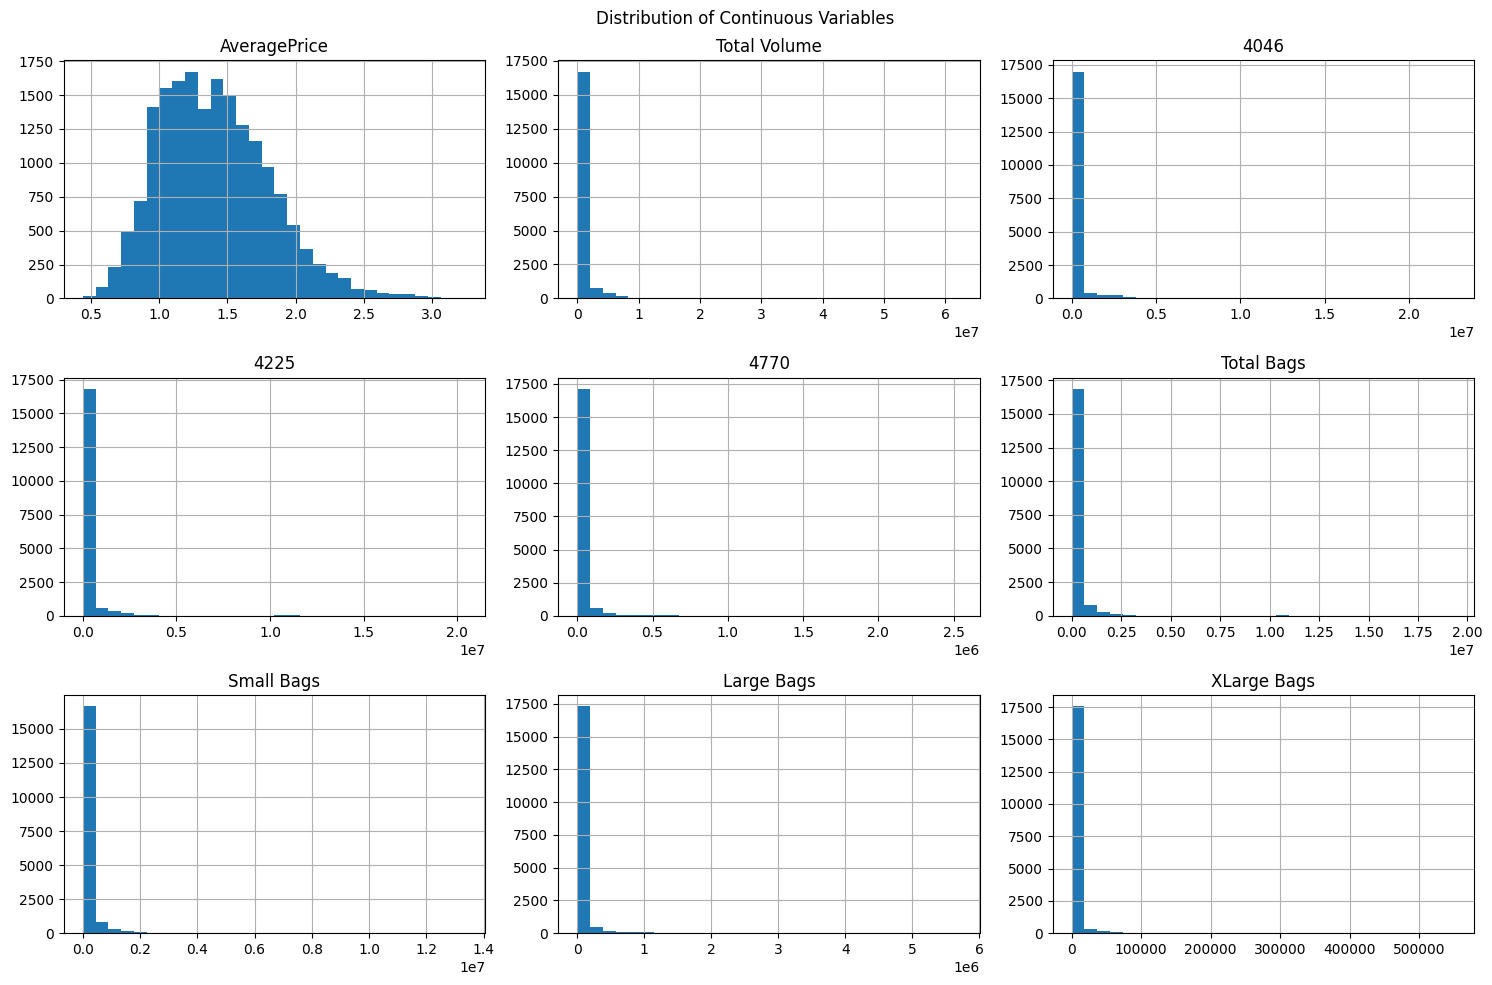


Variable: Date
  Unique Count: 170
  Values (First 5): ['12-27-2015' '12-20-2015' '12-13-2015' '12-6-2015' '11-29-2015'] ...

Variable: type
  Unique Count: 2
  Values: ['conventional' 'organic']

Variable: year
  Unique Count: 5
  Values: ['2015' '2016' '2017' '2018' '1904']

Variable: region
  Unique Count: 54
  Values (First 5): ['Albany' 'Atlanta' 'BaltimoreWashington' 'Boise' 'Boston'] ...


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# loading the dataset + basic cleaning
df = pd.read_csv('Assignment 2 dataset.csv')
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)
df.drop_duplicates(inplace=True)

# figuring out which rows have too many missing values and dropping them
missing_counts = df.isnull().sum(axis=1)
threshold = len(df.columns) / 2
rows_to_drop = df[missing_counts > threshold].index
df.drop(index=rows_to_drop, inplace=True)

# filling missing numeric values using region-based medians
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df.groupby('region')[col].transform('median'))

# listing continuous vs categorical variables
continuous_vars = df.select_dtypes(include=[np.number]).columns
categorical_vars = df.select_dtypes(include=['object']).columns

print(f"Continuous Variables: {list(continuous_vars)}")
print(f"Categorical Variables: {list(categorical_vars)}")

# printing out basic stats for each numeric column
for col in continuous_vars:
    print(f"\nVariable: {col}")
    print(f"  Range: {df[col].min()} to {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")

# plotting histograms for the continuous variables
df[continuous_vars].hist(bins=30, figsize=(15, 10), layout=(3, 3))
plt.suptitle('Distribution of Continuous Variables')
plt.tight_layout()
plt.show()

# checking unique values for each categorical variable
for col in categorical_vars:
    unique_vals = df[col].unique()
    num_unique = len(unique_vals)
    print(f"\nVariable: {col}")
    print(f"  Unique Count: {num_unique}")
    if num_unique < 20:
        print(f"  Values: {unique_vals}")
    else:
        print(f"  Values (First 5): {unique_vals[:5]} ...")

3.2 Inspect the earliest recorded date
- Find the earliest `Date`.
- Check if there are avocado prices recorded from the earliest date up to 2010.
- Comment: does the earliest data point look reasonable? Keep or remove?

In [20]:
import pandas as pd

# loading the dataset and doing basic cleanup
df = pd.read_csv('Assignment 2 dataset.csv')
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)
df.drop_duplicates(inplace=True)

# converting the 'Date' column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# finding the earliest date in the dataset
earliest_date = df['Date'].min()
print(f"Earliest Date Found: {earliest_date}")

# identifying any records from 2010 or earlier
ancient_avocados = df[df['Date'].dt.year <= 2010]

print(f"\nNumber of records from 2010 or earlier: {len(ancient_avocados)}")

# if there are obviously wrong dates, show and remove them
if len(ancient_avocados) > 0:
    print("\nSuspicious Data Points:")
    print(ancient_avocados)

    print("\nAction: Removing these records because 1904 is clearly a data entry error.")
    df = df[df['Date'].dt.year > 2010]

    print(f"New Earliest Date after cleaning: {df['Date'].min()}")
else:
    print("\nAction: No unreasonable dates found. All good.")


Earliest Date Found: 1904-01-21 00:00:00

Number of records from 2010 or earlier: 1

Suspicious Data Points:
            Date  AveragePrice  Total Volume     4046     4225    4770  \
18250 1904-01-21          1.87      13766.76  1191.92  2452.79  727.94   

       Total Bags  Small Bags  Large Bags  XLarge Bags     type  year  \
18250     9394.11      9351.8       42.31          0.0  organic  1904   

                 region  
18250  WestTexNewMexico  

Action: Removing these records because 1904 is clearly a data entry error.
New Earliest Date after cleaning: 2015-01-04 00:00:00


3.3 Highest average price
- Find the highest value in "AveragePrice".
- Report which region it belongs to.
- Describe how you obtained the result.

In [21]:
import pandas as pd
import numpy as np

# loading the dataset and doing some basic cleanup
df = pd.read_csv('Assignment 2 dataset.csv')
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)
df.drop_duplicates(inplace=True)

# dropping rows with too many missing values
missing_counts = df.isnull().sum(axis=1)
df = df[missing_counts <= (len(df.columns)/2)]

# filling missing numeric values with regional medians
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df.groupby('region')[col].transform('median'))

# fixing the 'Date' column and removing obviously wrong old dates
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].dt.year > 2010]

# finding the highest average price in the dataset
max_price = df['AveragePrice'].max()

# getting the row(s) with that highest price
highest_price_row = df[df['AveragePrice'] == max_price]

# printing the result
print(f"The Highest Average Price is: ${max_price}")
print("\nDetails for the record(s) with this price:")
print(highest_price_row[['region', 'Date', 'type', 'AveragePrice']])


The Highest Average Price is: $3.25

Details for the record(s) with this price:
             region       Date     type  AveragePrice
14125  SanFrancisco 2016-10-30  organic          3.25


3.4 Highest total volume
- Find the highest total volume of avocados.
- Report which region it belongs to.
- Describe how you obtained the result.

In [22]:
import pandas as pd
import numpy as np

# load the dataset and do basic cleanup
df = pd.read_csv('Assignment 2 dataset.csv')
df.drop(columns=['Column 1'], inplace=True)
df['year'] = df['year'].astype(str)
df.drop_duplicates(inplace=True)

# drop rows with too many missing values
missing_counts = df.isnull().sum(axis=1)
df = df[missing_counts <= (len(df.columns)/2)]

# fill missing numeric values with regional medians
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df.groupby('region')[col].transform('median'))

# fix 'Date' column and remove obviously wrong old dates
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'].dt.year > 2010]

# find the highest total volume in the dataset
max_volume = df['Total Volume'].max()

# get the row(s) with that highest volume
highest_volume_row = df[df['Total Volume'] == max_volume]

# print the results
print(f"The Highest Total Volume is: {max_volume:,.2f}")
print("\nDetails for the record(s) with this volume:")
print(highest_volume_row[['region', 'Date', 'type', 'Total Volume']])


The Highest Total Volume is: 62,505,646.52

Details for the record(s) with this volume:
       region       Date          type  Total Volume
9097  TotalUS 2018-02-04  conventional   62505646.52
